# Qutritium Tutorial: Noise & State Tomography

We'll add noise to a circuit and then reconstruct a state from measurement
counts — the two big things v1.4 brings:

1. Attaching a `NoiseModel` to the density-matrix simulator
2. Gate (Kraus) errors, prep errors, and classical readout error
3. The one-call `SPAMNoiseModel`
4. Single-qutrit MUB state tomography
5. Plotting the reconstructed density matrix

In [1]:
import numpy as np

import qutritium
from qutritium import DensityMatrixSimulator, QASMSimulator, QutritCircuit
from qutritium.channels import depolarizing_channel, NoiseModel, SPAMNoiseModel
from qutritium.gates import H3, X01

print(f"Qutritium version: {qutritium.__version__}")

Qutritium version: 1.4.0


## 1. Noise lives on the simulator

The circuit stays pure-unitary — noise goes on the *simulator*. We build a
`NoiseModel` and attach it with `set_noise_model`. `add_quantum_error` says
\"apply this channel after every gate with this label,\" so below a 10%
depolarizing channel follows each `X01`: the ideal $|0angle 	o |1angle$
leaks a little into $|0angle$ and $|2angle$.

In [2]:
qc = QutritCircuit(1, None)
qc.append(X01(), first_qutrit=0)  # |0> -> |1>
qc.measure_all()

nm = NoiseModel()
nm.add_quantum_error(depolarizing_channel(0.1), "X01")

dm = DensityMatrixSimulator(qc)
dm.set_noise_model(nm)
dm.run(num_shots=5000)
print("noisy counts:", dm.get_counts())

noisy counts: {'1': 4681, '2': 159, '0': 160}


Three things to remember:

- Kraus channels (gate and prep errors) only run on the `DensityMatrixSimulator`.
  Hand one to the statevector `QASMSimulator` and it refuses with a
  `NotImplementedError`.
- Attach the model *before* you call `run()`. The simulation gets cached, so a
  model added afterward raises instead of being silently ignored.
- Readout error is classical, so it works on both simulators.

## 2. Prep errors and readout error

A prep error is a Kraus channel applied once before the gates. Fully depolarize
the input and you get a uniform distribution no matter what the circuit does.

In [3]:
prep_nm = NoiseModel()
prep_nm.add_prep_error(depolarizing_channel(1.0))  # qutrit=None -> all qutrits

qc_h = QutritCircuit(1, None)
qc_h.append(H3(), first_qutrit=0)
qc_h.measure_all()

dm_prep = DensityMatrixSimulator(qc_h)
dm_prep.set_noise_model(prep_nm)
print("prep-depolarized probabilities:", dm_prep.probabilities().round(3))

prep-depolarized probabilities: [0.333 0.333 0.333]


A readout error is the classical kind — a confusion matrix on the probability
vector — so it works on either simulator.

In [4]:
from qutritium.channels import ReadoutError

conf = np.array([[0.9, 0.05, 0.05],
                 [0.05, 0.9, 0.05],
                 [0.05, 0.05, 0.9]])
ro_nm = NoiseModel()
ro_nm.add_readout_error(ReadoutError(conf))

qsim = QASMSimulator(qc_h)
qsim.set_noise_model(ro_nm)
qsim.run(num_shots=5000)
print("counts with readout error:", qsim.get_counts())

counts with readout error: {'1': 1670, '2': 1643, '0': 1687}


## 3. SPAM in one line

If you just want some state-prep plus measurement error, `SPAMNoiseModel` builds
both halves for you. It carries a Kraus prep channel, so it's density-matrix only.

In [5]:
qc_x = QutritCircuit(1, None)
qc_x.append(X01(), first_qutrit=0)
qc_x.measure_all()

dm_spam = DensityMatrixSimulator(qc_x)
dm_spam.set_noise_model(SPAMNoiseModel(p_prep=0.03, p_meas=0.05))
dm_spam.run(num_shots=5000)
print("SPAM counts:", dm_spam.get_counts())

SPAM counts: {'1': 4602, '0': 214, '2': 184}


## 4. State tomography

Say you've prepared a state and want to know what it actually is. Measure it in
all four MUBs and invert. Start from a *prep* circuit with no measurement, run
the four returned circuits **in order**, and feed their counts to
`reconstruct_state`.

In [6]:
from qutritium import state_fidelity
from qutritium.tomography import state_tomography_circuits, reconstruct_state

prep = QutritCircuit(1, None)
prep.append(H3(), first_qutrit=0)  # the state to reconstruct

counts = []
for circ in state_tomography_circuits(prep):
    sim = QASMSimulator(circ)
    sim.run(num_shots=20000)
    counts.append(sim.get_counts())  # keep the basis order!

rho_est = reconstruct_state(counts)
rho_true = DensityMatrixSimulator(prep).return_final_state()
fid = state_fidelity(rho_true, rho_est)
print(f"reconstructed fidelity: {fid:.4f}")

reconstructed fidelity: 1.0000


## 5. Look at the reconstruction

`plot_tomography_comparison` puts the ideal and reconstructed density matrices
side by side as 3D \"cityscape\" bars (needs `pip install qutritium[plot]`).

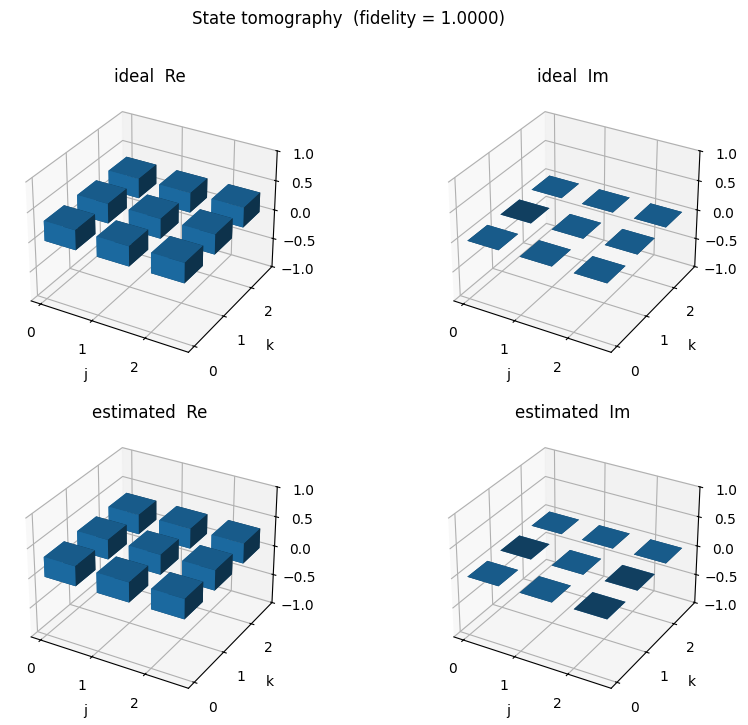

In [7]:
import matplotlib.pyplot as plt
from qutritium.tomography import plot_tomography_comparison

fig = plot_tomography_comparison(rho_true, rho_est, fidelity=fid)
plt.show()

## Summary

- Noise sits on the *simulator* (`set_noise_model`), not the circuit — so one
  circuit runs noiseless or noisy just by handing fresh simulators different
  models.
- Kraus channels run on the `DensityMatrixSimulator`; classical readout works on
  both.
- MUB tomography reconstructs a single-qutrit state to high fidelity from counts
  via linear inversion (you can get a slightly unphysical estimate at low shot
  counts).

The **Channels & Noise** and **Tomography** API pages have the full reference.